In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [2]:
from google.colab import files
uploaded = files.upload()


Saving European_Bank.csv to European_Bank.csv


In [3]:
df = pd.read_csv('European_Bank.csv')

In [ ]:
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:

df.describe(include='all')

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,2932,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Smith,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,32,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2025.0,1.569094e+07,NaN,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,NaN,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,NaN,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,NaN,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,NaN,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,NaN,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000


In [6]:
corr_df = df.corr(numeric_only=True)
corr_df

,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
Year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerId,NaN,1.000000,0.005308,0.009497,-0.014883,-0.012419,0.016972,-0.014025,0.001665,0.015271,-0.006248
CreditScore,NaN,0.005308,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
Age,NaN,0.009497,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,NaN,-0.014883,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
Balance,NaN,-0.012419,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
NumOfProducts,NaN,0.016972,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
HasCrCard,NaN,-0.014025,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
IsActiveMember,NaN,0.001665,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
EstimatedSalary,NaN,0.015271,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097


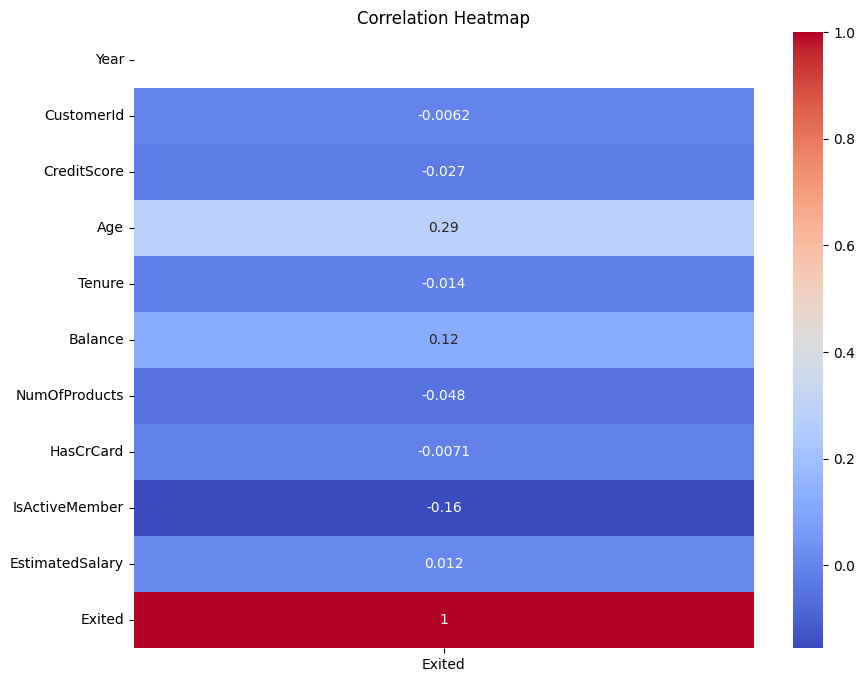

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_df[['Exited']], annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

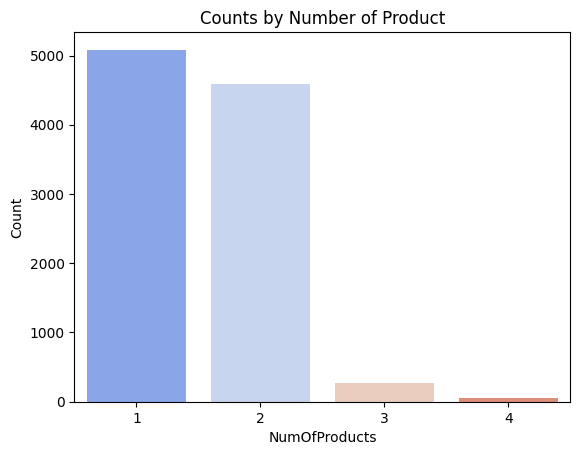

In [8]:
df_NumOfProducts = pd.DataFrame({'NumOfProducts': df['NumOfProducts'].value_counts().index,
                                 'Count': df['NumOfProducts'].value_counts().values})
df_NumOfProducts

# Correct bar plot
sns.barplot(x="NumOfProducts", y="Count", data=df_NumOfProducts, palette="coolwarm")

plt.title("Counts by Number of Product")

plt.show()


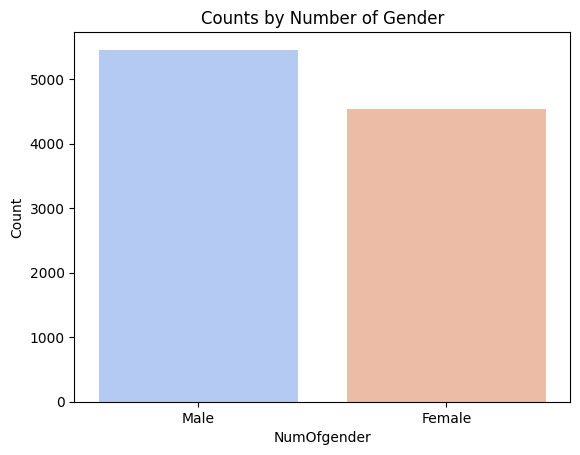

In [9]:
df_NumOfgender = pd.DataFrame({'NumOfgender': df['Gender'].value_counts().index,
                                 'Count': df['Gender'].value_counts().values})
df_NumOfgender

# Correct bar plot
sns.barplot(x="NumOfgender", y="Count", data=df_NumOfgender, palette="coolwarm")

plt.title("Counts by Number of Gender")

plt.show()

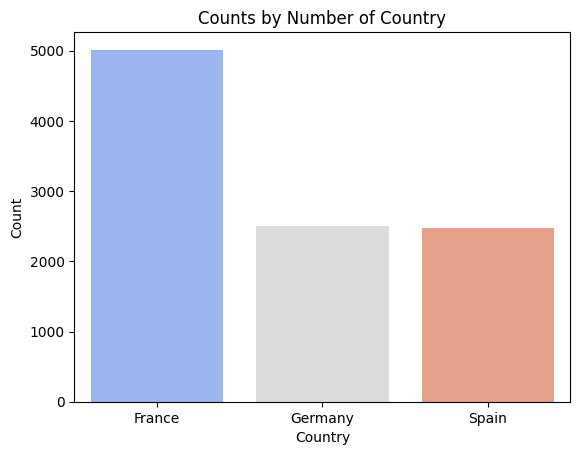

In [10]:
df_Geography = pd.DataFrame({'Country': df['Geography'].value_counts().index,
                                 'Count': df['Geography'].value_counts().values})

# Correct bar plot
sns.barplot(x="Country", y="Count", data=df_Geography, palette="coolwarm")

plt.title("Counts by Number of Country")

plt.show()

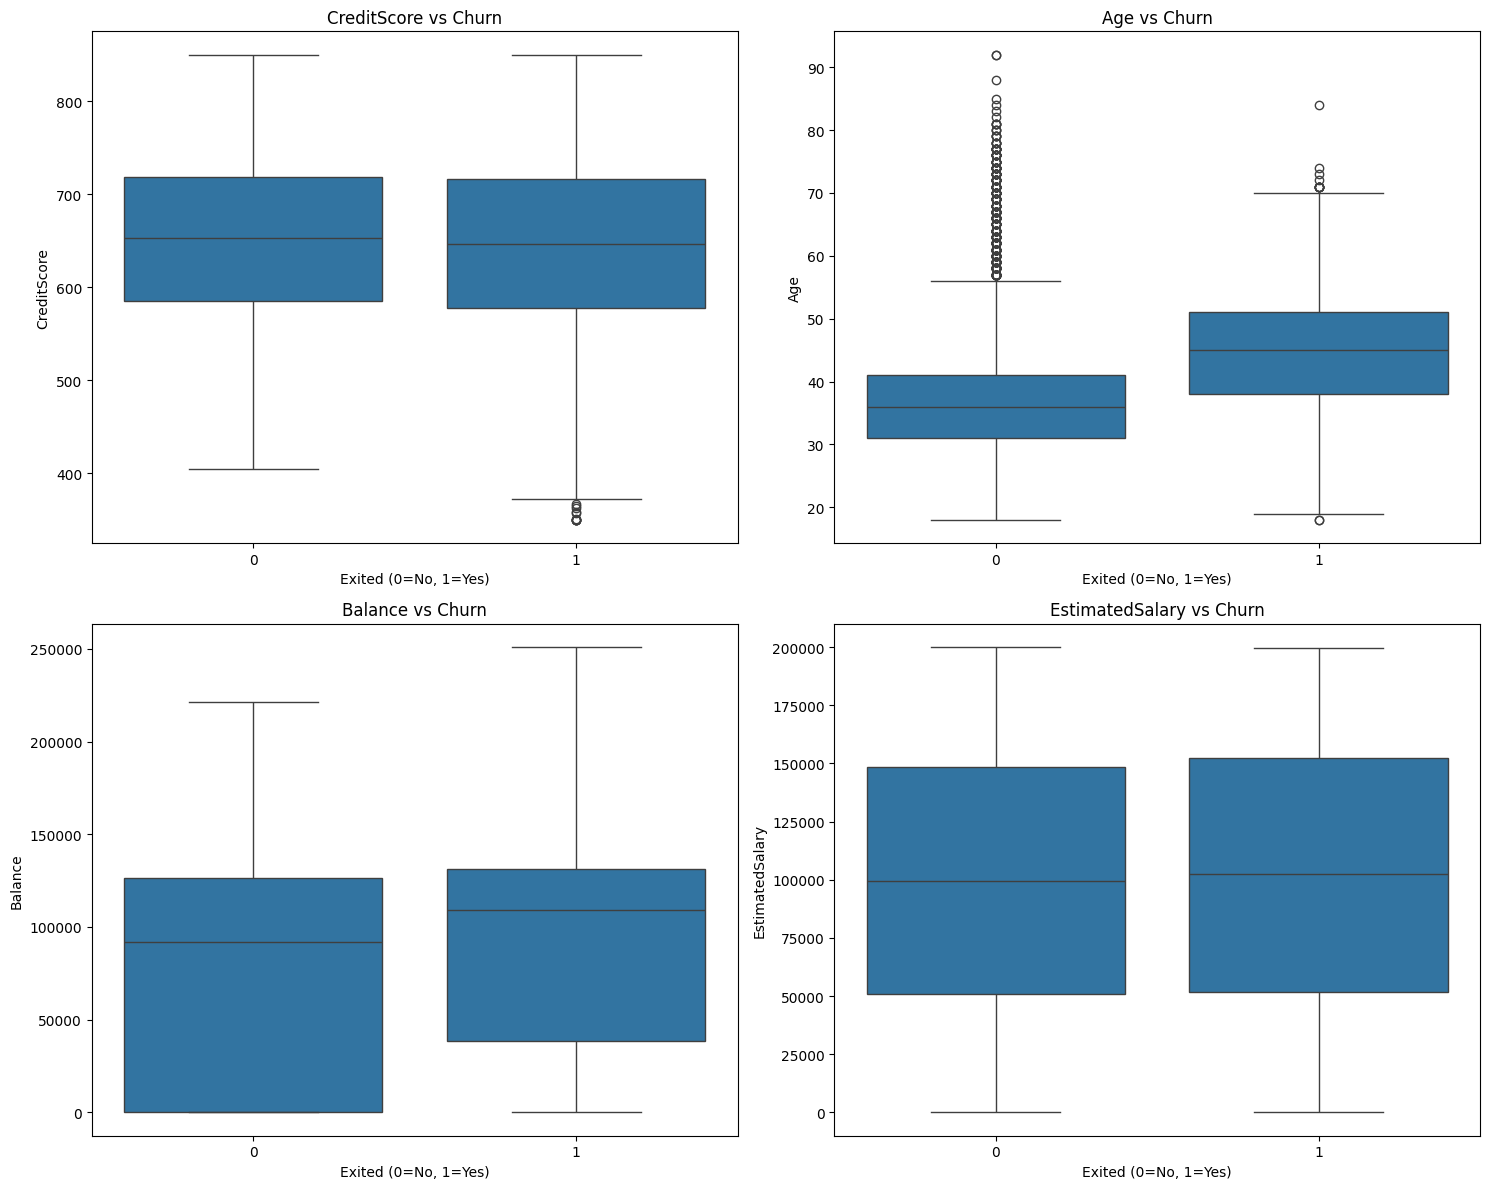

In [11]:
numeric_cols = ["CreditScore", "Age", "Balance", "EstimatedSalary"]

fig, axes = plt.subplots(2, 2, figsize=(15, 12)) # Create a 2x2 grid of subplots
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(numeric_cols):
  sns.boxplot(x="Exited", y=col, data=df, ax=axes[i]) # Plot on the i-th subplot
  axes[i].set_title(f"{col} vs Churn") # Set title for each subplot
  axes[i].set_xlabel("Exited (0=No, 1=Yes)") # Set consistent x-axis label

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels

plt.show()

In [12]:
df.columns

Index(['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

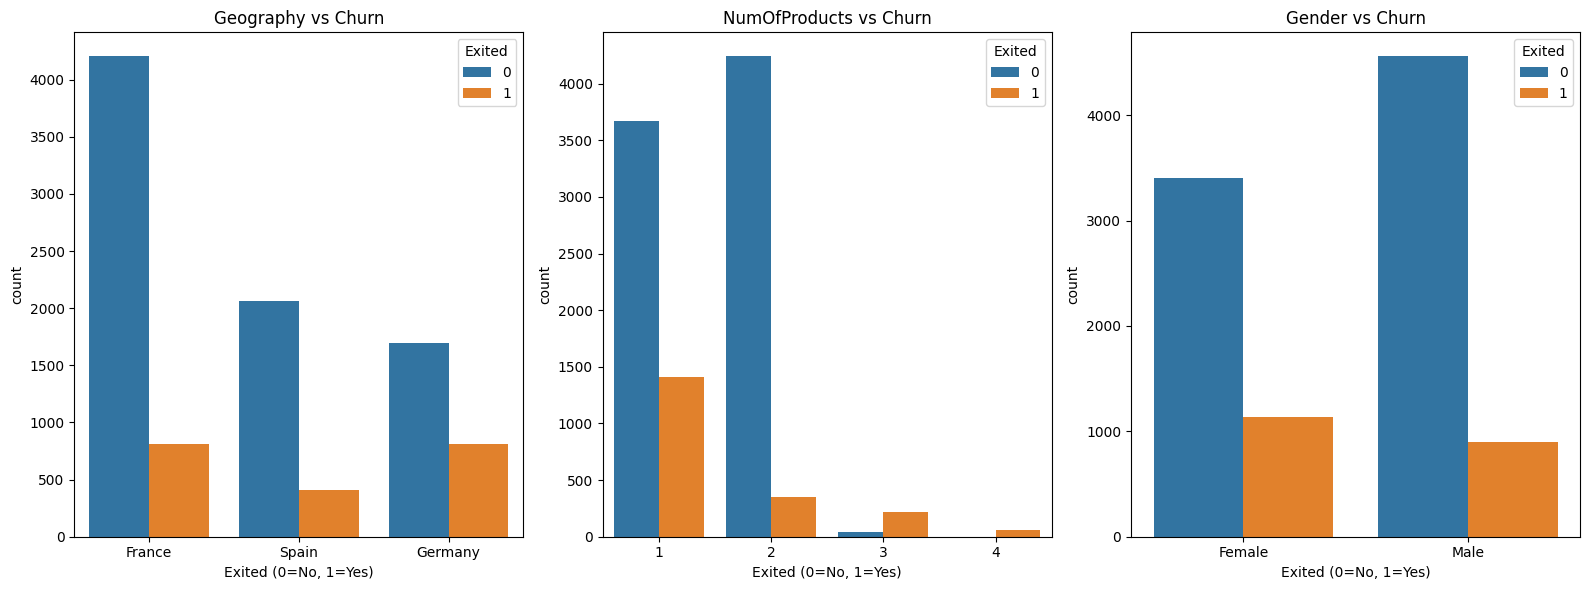

In [14]:
categorical_col = ['Geography','NumOfProducts','Gender']

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
axes = axes.flatten()
for i, col in enumerate(categorical_col):
  sns.countplot(x =col,hue="Exited", data=df, ax=axes[i]) # Plot on the i-th subplot
  axes[i].set_title(f"{col} vs Churn") # Set title for each subplot
  axes[i].set_xlabel("Exited (0=No, 1=Yes)") # Set consistent x-axis label

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels

plt.show()

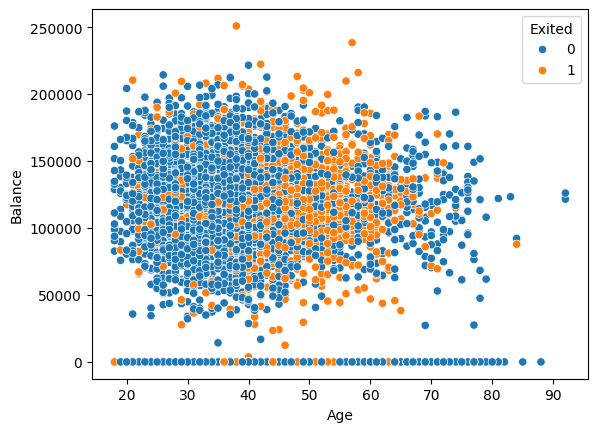

In [13]:
sns.scatterplot(x="Age", y="Balance", hue="Exited", data=df)

plt.show()

In [15]:
df.isnull().sum()

,0
Year,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [17]:
df = df.drop(['Surname','CustomerId'],axis=1)

In [19]:
df.columns

Index(['Year', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited'],
      dtype='object')

Derived Feature

In [20]:
df["BalanceSalaryRatio"] = df["Balance"] / (df["EstimatedSalary"] + 1)
df["ProductDensity"] = df["NumOfProducts"] / (df["Tenure"] + 1)
df["EngagementProduct"] = df["IsActiveMember"] * df["NumOfProducts"]
df["AgeTenureInteraction"] = df["Age"] * df["Tenure"]

In [21]:
df

,Year,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,ProductDensity,EngagementProduct,AgeTenureInteraction
0,2025,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000,0.333333,1,84
1,2025,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.744670,0.500000,1,41
2,2025,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401362,0.333333,0,336
3,2025,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000,1.000000,0,39
4,2025,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.587035,0.333333,1,86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2025,771,France,Male,39,5,0.00,2,1,0,96270.64,0,0.000000,0.333333,0,195
9996,2025,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,0.564102,0.090909,1,350
9997,2025,709,France,Female,36,7,0.00,1,0,1,42085.58,1,0.000000,0.125000,1,252
9998,2025,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,0.808222,0.500000,0,126


In [22]:
#Feature Engineering

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

X = df.drop("Exited", axis=1)
y = df["Exited"]

# -------------------------------
# Column Groups
# -------------------------------
categorical_cols = ["Geography", "Gender"]
numeric_cols = [col for col in X.columns if col not in categorical_cols]

# -------------------------------
# Preprocessing Pipelines
# -------------------------------
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("categorical", categorical_pipeline, categorical_cols),
    ("numeric", numeric_pipeline, numeric_cols)
])

# -------------------------------
# Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# -------------------------------
# Apply Preprocessing
# -------------------------------
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)


Processed training shape: (8000, 18)
Processed test shape: (2000, 18)


In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,confusion_matrix
from sklearn.metrics import classification_report,ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import xgboost as xgb
import lightgbm as lgb

#
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(
                           random_state=42
                                                  ),
    "LGBM Classifier":lgb.LGBMClassifier(
                          random_state=42,
                          n_estimators=200,
                          learning_rate=0.05,
                          max_depth=-5,
                          is_unbalance=True),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
}

# -------------------------------
# Training + Evaluation
# -------------------------------
results = {}

for name, model in models.items():
    clf = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:,1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

# -------------------------------
# Display Results
# -------------------------------
results_df = pd.DataFrame(results).T
print(results_df)
print(classification_report(y_test, y_pred))

[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007299 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1412
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019
                     Accuracy  Precision    Recall  F1-Score   ROC-AUC
Logistic Regression    0.8060   0.570370  0.189189  0.284133  0.773501
Decision Tree          0.7845   0.471429  0.486486  0.478839  0.673563
Random Forest          0.8620   0.767347  0.461916  0.576687  0.853149
Gradient Boosting      0.8705   0.791339  0.493857  0.608169  0.867384
LGBM Classifier        0.8190   0.542056  0.712531  0.615711  0.857776
XGBoost                0.8490   0.675585  0.496314  0.572238  0.831130
            

In [27]:
import joblib

# Dictionary to hold fitted pipelines
all_models = {}

for name, model in models.items():
    clf = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])
    clf.fit(X_train, y_train)
    all_models[name] = clf

    # Save each model separately
    filename = f"{name.replace(' ', '_').lower()}_models12.pkl"
    joblib.dump(clf, filename)
    print(f"Saved {filename}")


Saved logistic_regression_models12.pkl
Saved decision_tree_models12.pkl
Saved random_forest_models12.pkl
Saved gradient_boosting_models12.pkl
[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000365 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1412
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019
Saved lgbm_classifier_models12.pkl
Saved xgboost_models12.pkl


In [28]:
# Save dictionary of all models
import joblib

joblib.dump(all_models, "all_models12.pkl")

# Download one file
from google.colab import files
files.download("all_models12.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)



Confusion Matrix:
 [[1496   97]
 [ 205  202]]


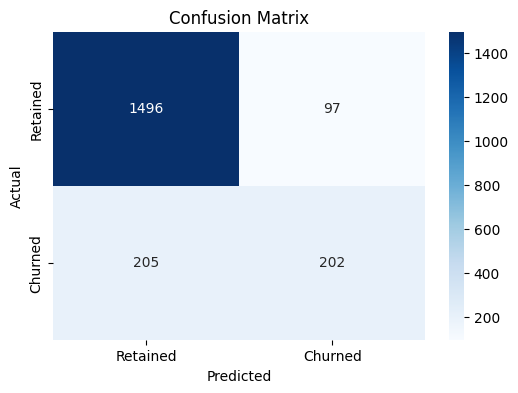

In [30]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=["Retained","Churned"], yticklabels=["Retained","Churned"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000409 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1412
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019


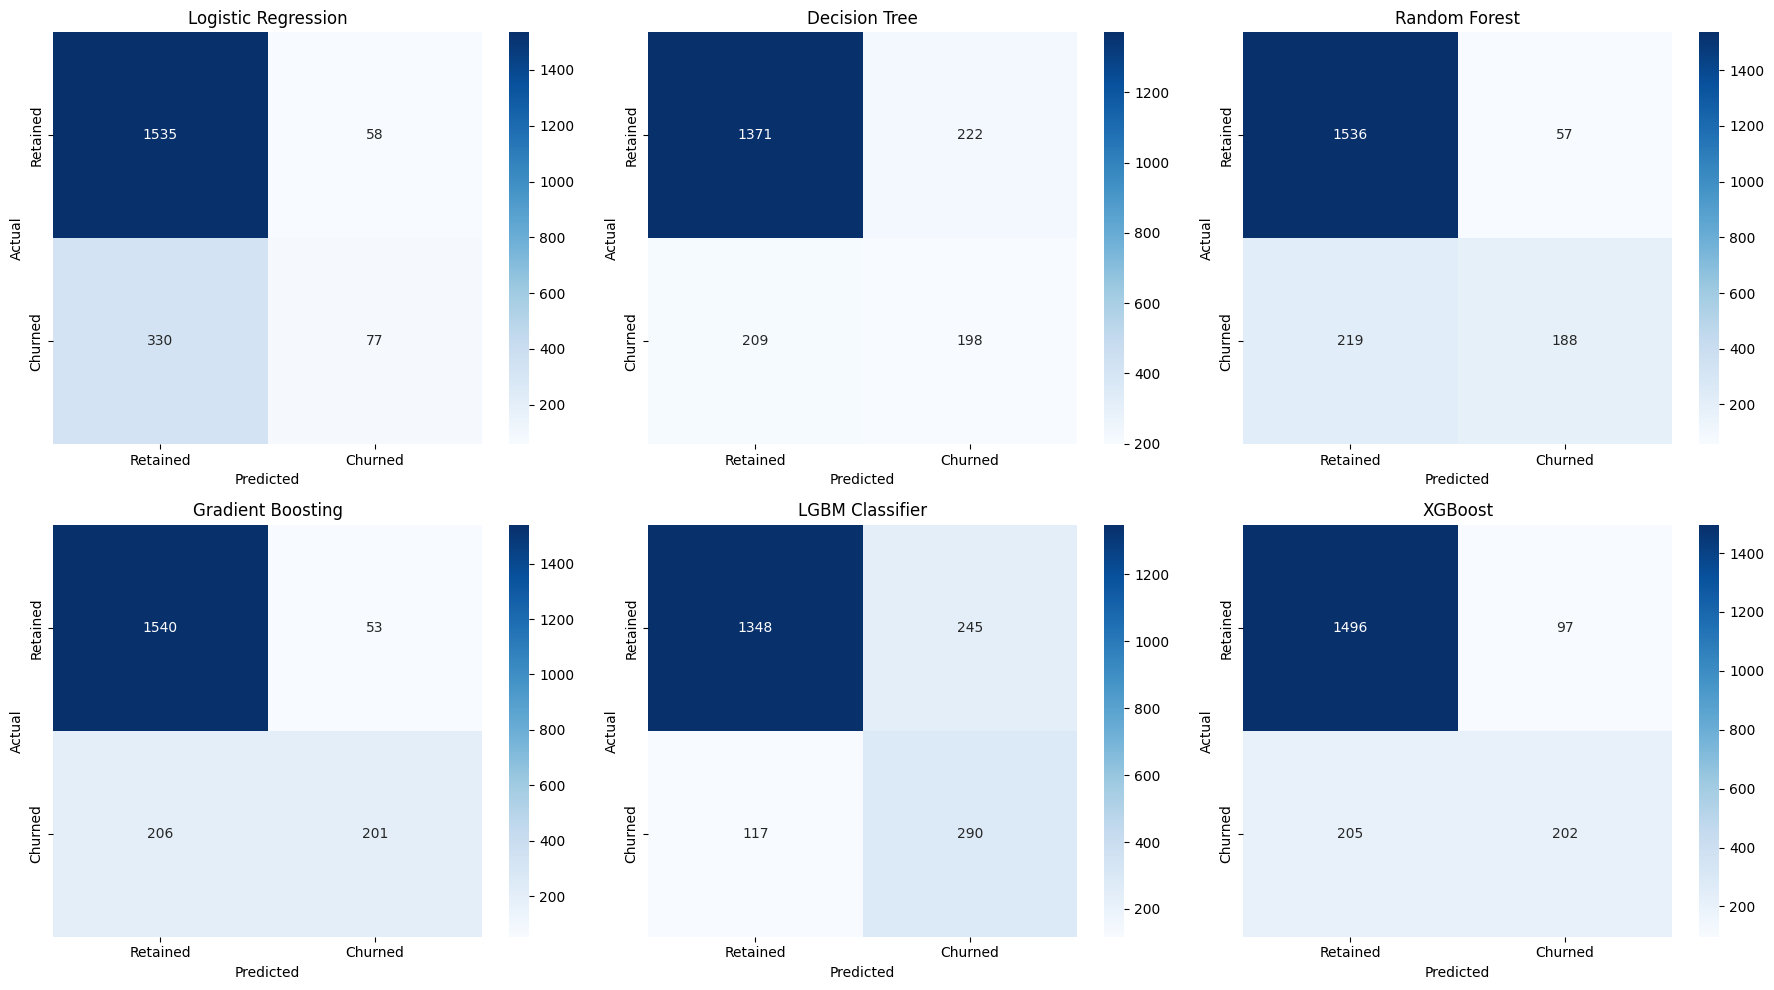

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# -------------------------------
# Confusion Matrices for All Models
# -------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))  # 2 rows × 3 columns for 6 models
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    # Rebuild pipeline with preprocessor + classifier
    clf = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
                xticklabels=["Retained", "Churned"],
                yticklabels=["Retained", "Churned"],
                ax=axes[idx])
    axes[idx].set_title(name)
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrices.png")
plt.show()


In [32]:
from sklearn.ensemble import GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline

# -------------------------------
# Base learners
# -------------------------------
gb_clf = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

lgbm_clf = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

# -------------------------------
# Meta learner
# -------------------------------
meta_clf = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# -------------------------------
# Stacking ensemble
# -------------------------------
stacked_clf = StackingClassifier(
    estimators=[
        ("gb", gb_clf),
        ("lgbm", lgbm_clf)
    ],
    final_estimator=meta_clf,
    cv=5,                # 5-fold cross-validation for blending
    n_jobs=-1
)

# -------------------------------
# Pipeline with preprocessing
# -------------------------------
clf = Pipeline(steps=[
    ("preprocessor", preprocessor),  # your preprocessing pipeline
    ("model", stacked_clf)
])

# -------------------------------
# Fit & Evaluate
# -------------------------------
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

from sklearn.metrics import classification_report, roc_auc_score
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, clf.predict_proba(X_test)[:,1]))


              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.78      0.49      0.60       407

    accuracy                           0.87      2000
   macro avg       0.83      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000

ROC-AUC: 0.8676318845810372


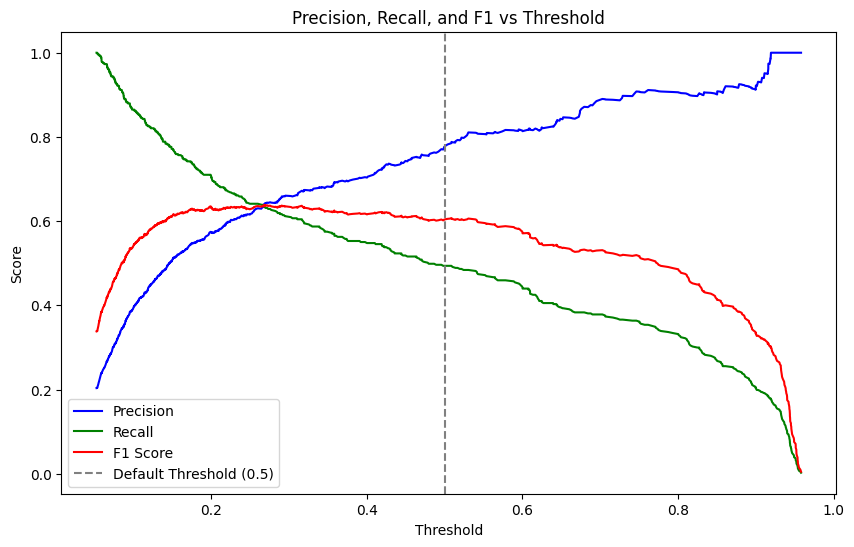

Best Threshold: 0.26831563715107887
Precision: 0.6410891089108911
Recall: 0.6363636363636364
F1 Score: 0.6387176325524044


In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score

# Get predicted probabilities
y_proba = clf.predict_proba(X_test)[:,1]

# Compute precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# Compute F1 scores for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)

# Plot Precision-Recall vs Threshold
plt.figure(figsize=(10,6))
plt.plot(thresholds, precisions[:-1], label="Precision", color="blue")
plt.plot(thresholds, recalls[:-1], label="Recall", color="green")
plt.plot(thresholds, f1_scores[:-1], label="F1 Score", color="red")
plt.axvline(0.5, color="gray", linestyle="--", label="Default Threshold (0.5)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 vs Threshold")
plt.legend()
plt.show()

# Find threshold that maximizes F1
best_idx = f1_scores.argmax()
print("Best Threshold:", thresholds[best_idx])
print("Precision:", precisions[best_idx])
print("Recall:", recalls[best_idx])
print("F1 Score:", f1_scores[best_idx])


In [34]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier

clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])


In [35]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [3, 5],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 3]
}


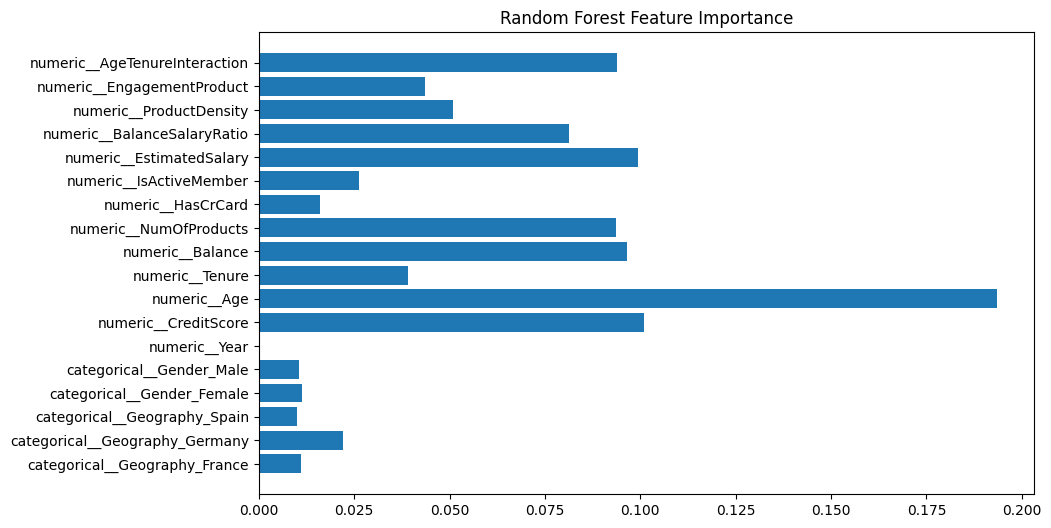

In [36]:
import matplotlib.pyplot as plt

# Example: Random Forest
rf_model = models["Random Forest"]
clf_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", rf_model)
])
clf_rf.fit(X_train, y_train)

# Extract feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()
importances = clf_rf.named_steps["classifier"].feature_importances_

# Plot
plt.figure(figsize=(10,6))
plt.barh(feature_names, importances)
plt.title("Random Forest Feature Importance")
plt.show()


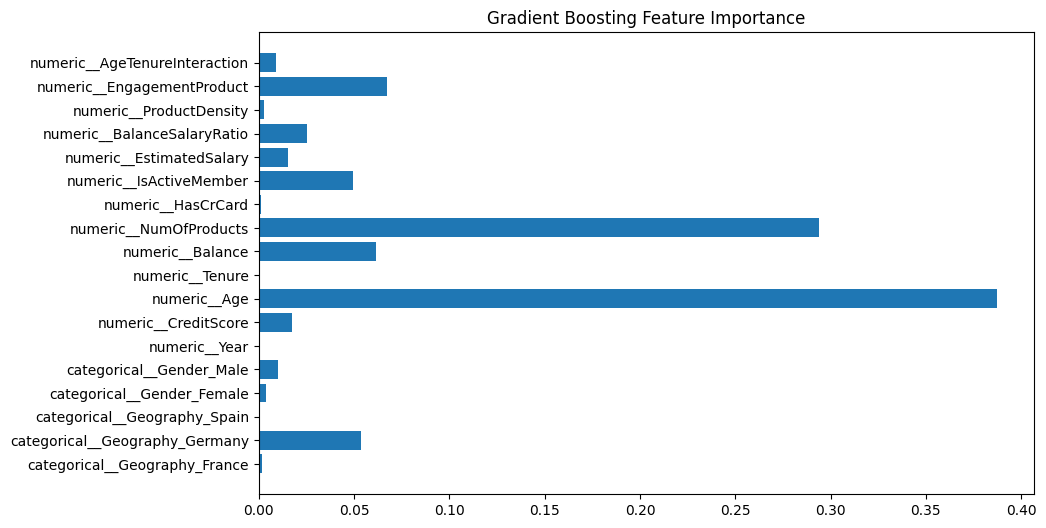

In [37]:
import shap

# Fit Gradient Boosting model
gb_model = models["Gradient Boosting"]
clf_gb = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", gb_model)
])
clf_gb.fit(X_train, y_train)

# SHAP analysis
feature_names = preprocessor.get_feature_names_out()
importances = clf_gb.named_steps["classifier"].feature_importances_
# Summary plot
plt.figure(figsize=(10,6))
plt.barh(feature_names, importances)
plt.title("Gradient Boosting Feature Importance")
plt.show()


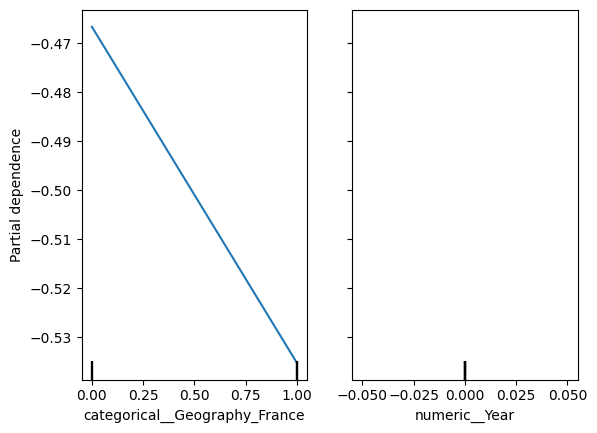

In [38]:
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(
    clf_gb.named_steps["classifier"],
    X_test_processed,
    features=[0, 5],  # Example: CreditScore, Age
    feature_names=preprocessor.get_feature_names_out()
)
plt.show()


 99%|===================| 1989/2000 [03:05<00:01]       

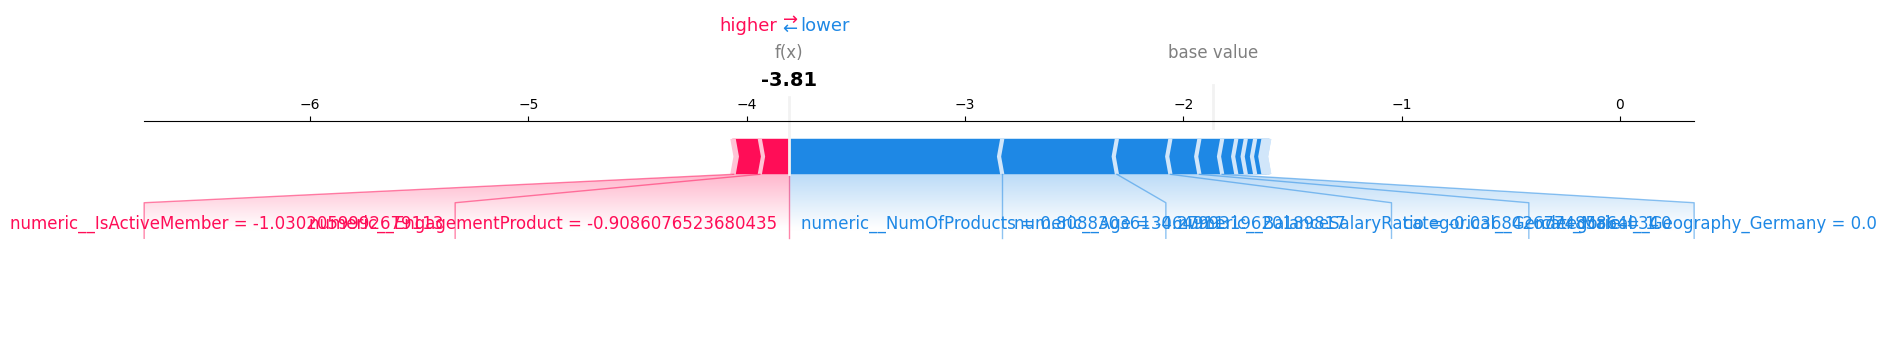

In [39]:
import shap

# -------------------------------
# SHAP Force Plot (Individual Customer)
# --------------------------------
# Pick one customer from test set
sample_idx = 0  # change index to explore different customers

# Create a masker with all background samples to avoid subsampling warning
masker = shap.maskers.Independent(X_train_processed, max_samples=X_train_processed.shape[0])

# Initialize SHAP explainer for the Gradient Boosting model
explainer = shap.Explainer(clf_gb.named_steps["classifier"], masker)

# Calculate SHAP values for the test set
shap_values = explainer(X_test_processed)

# Explain prediction for this customer
shap.initjs()
shap.force_plot(
    explainer.expected_value,               # Global base value
    shap_values.values[sample_idx],         # SHAP values for the specific sample (1D numpy array)
    X_test_processed[sample_idx],           # Original feature values for the specific sample
    feature_names=preprocessor.get_feature_names_out(),
    matplotlib=True
)

In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [41]:
X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

# Create DataLoader for batching
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [42]:
class ChurnNet(nn.Module):
    def __init__(self, input_dim):
        super(ChurnNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        self.dropout = nn.Dropout(0.3)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.sigmoid(self.fc3(x))
        return x


In [43]:
input_dim = X_train_processed.shape[1]
model = ChurnNet(input_dim)

criterion = nn.BCELoss()  # binary cross entropy
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [44]:
epochs = 50
for epoch in range(epochs):
    model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch).squeeze()
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")


Epoch 10/50, Loss: 0.4247
Epoch 20/50, Loss: 0.2893
Epoch 30/50, Loss: 0.3462
Epoch 40/50, Loss: 0.4782
Epoch 50/50, Loss: 0.3300


In [45]:
model.eval()
with torch.no_grad():
    y_pred_proba = model(X_test_tensor).squeeze()
    y_pred = (y_pred_proba >= 0.5).int()

from sklearn.metrics import classification_report, roc_auc_score
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba.numpy()))


              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.78      0.47      0.59       407

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000

ROC-AUC: 0.8630541172914055


In [46]:
files.download('Customer_churner.ipynb')

FileNotFoundError: Cannot find file: Customer_churner.ipynb